# Predicting F1 Pit Stops - Kaggle Playground Series S6E5

Predict whether a Formula 1 driver will pit on the next lap (`PitNextLap`) from lap-level telemetry and race context.

The data has about 439,000 training laps and 188,000 test laps. Roughly 20% of laps are followed by a pit stop, and models are scored on ROC AUC.

## 1. Setup and data

In [1]:
from pathlib import Path
import json
import warnings

import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#dee2e6",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
sns.set_palette("viridis")

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

SEED = 42
N_FOLDS = 5
TARGET = "PitNextLap"
ID_COL = "id"

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nColumns ({len(train.columns)}):")
for i, col in enumerate(train.columns):
    print(f"  {i+1:2d}. {col}  ({train[col].dtype})")

Train shape: (439140, 16)
Test shape:  (188165, 15)

Columns (16):
   1. id  (int64)
   2. Driver  (str)
   3. Compound  (str)
   4. Race  (str)
   5. Year  (int64)
   6. PitStop  (int64)
   7. LapNumber  (int64)
   8. Stint  (int64)
   9. TyreLife  (float64)
  10. Position  (int64)
  11. LapTime (s)  (float64)
  12. LapTime_Delta  (float64)
  13. Cumulative_Degradation  (float64)
  14. RaceProgress  (float64)
  15. Position_Change  (float64)
  16. PitNextLap  (float64)


In [3]:
train.head(10)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
5,5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0
6,6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0
7,7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0
8,8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0
9,9,YAM,MEDIUM,Hungarian Grand Prix,2023,0,2,1,2.0,8,84.726,-6.669,-6.669,0.028169,0.0,0.0


## 2. Exploratory data analysis

We start with the class balance and summary statistics, then look at how each feature relates to the target.

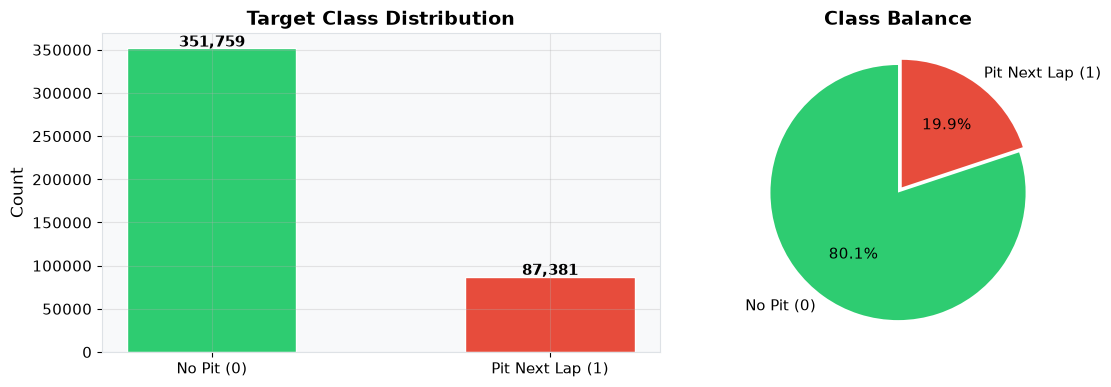

Class 0 (no pit): 351,759 (80.1%)
Class 1 (pit):    87,381 (19.9%)


In [4]:
target_counts = train[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["No Pit (0)", "Pit Next Lap (1)"], target_counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Target Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(target_counts.values, labels=["No Pit (0)", "Pit Next Lap (1)"], autopct="%1.1f%%",
            colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title("Class Balance", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Class 0 (no pit): {target_counts[0]:,} ({target_counts[0]/len(train):.1%})")
print(f"Class 1 (pit):    {target_counts[1]:,} ({target_counts[1]/len(train):.1%})")

The classes are imbalanced at roughly 4:1, which is why we use AUC rather than accuracy and stratify every split.

In [5]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.drop([ID_COL, TARGET])
train[numeric_cols].describe().T.style.background_gradient(cmap="viridis", axis=0).format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Year,439140.00,2023.52,1.02,2022.00,2023.00,2024.00,2024.00,2025.00
PitStop,439140.00,0.14,0.34,0.00,0.00,0.00,0.00,1.00
LapNumber,439140.00,23.11,16.96,1.00,9.00,19.00,36.00,78.00
Stint,439140.00,1.79,0.95,1.00,1.00,2.00,2.00,8.00
TyreLife,439140.00,14.16,9.80,1.00,6.00,12.00,20.00,77.00
Position,439140.00,9.63,5.28,1.00,5.00,10.00,14.00,20.00
LapTime (s),439140.00,90.95,19.77,67.69,82.62,90.52,98.47,2507.61
LapTime_Delta,439140.00,-3.77,43.95,-2403.89,-8.88,-0.30,0.11,2423.93
Cumulative_Degradation,439140.00,-25.72,54.77,-274.56,-46.57,-20.99,-6.20,2412.03
RaceProgress,439140.00,0.34,0.25,0.01,0.13,0.27,0.51,1.00


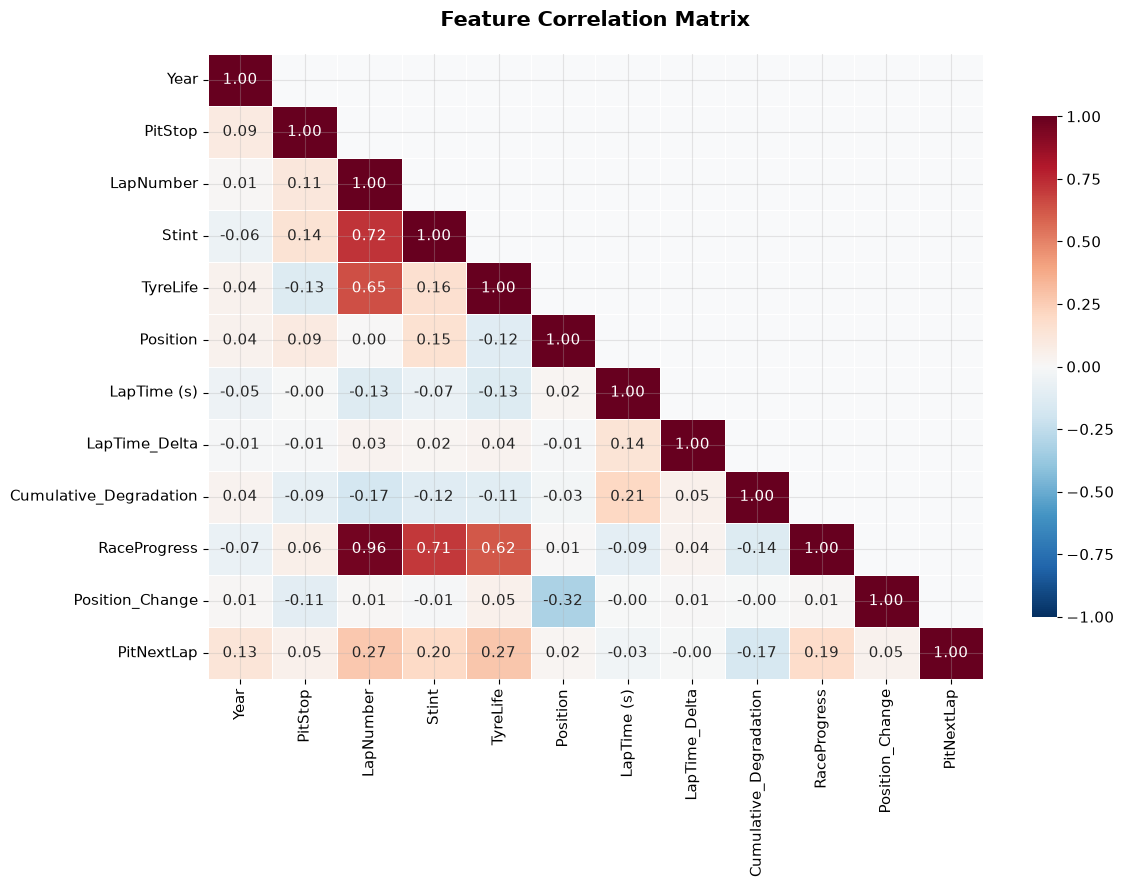

In [6]:
corr_cols = list(numeric_cols) + [TARGET]
corr_matrix = train[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontweight="bold", fontsize=15, pad=20)
plt.tight_layout()
plt.show()

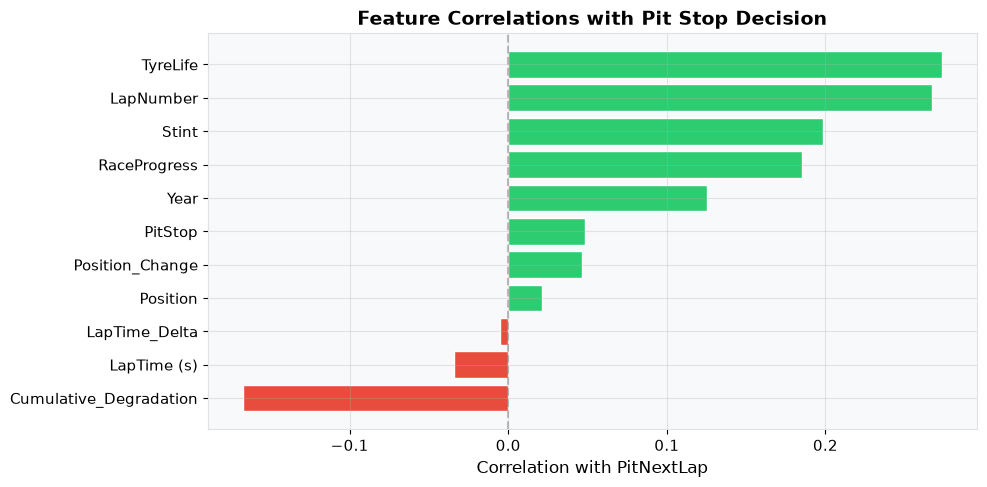

In [7]:
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ["#2ecc71" if v > 0 else "#e74c3c" for v in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=colors_bar, edgecolor="white")
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.set_xlabel("Correlation with PitNextLap")
ax.set_title("Feature Correlations with Pit Stop Decision", fontweight="bold")
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

No single feature is strongly correlated with the target. The largest correlation is only about 0.27, so the signal comes from combinations of features rather than any one of them.

- TyreLife (0.27) and LapNumber (0.27) have the strongest positive relationship: older tyres and later laps make a stop more likely.
- Stint (0.20) and RaceProgress (0.19) follow, reflecting the usual strategy windows.
- Cumulative_Degradation is negatively correlated (-0.17), which is counter-intuitive and suggests it is measured relative to a stint baseline rather than as raw wear.
- LapTime_Delta, Position and PitStop have almost no linear relationship with the target, although tree models can still find non-linear use for them.

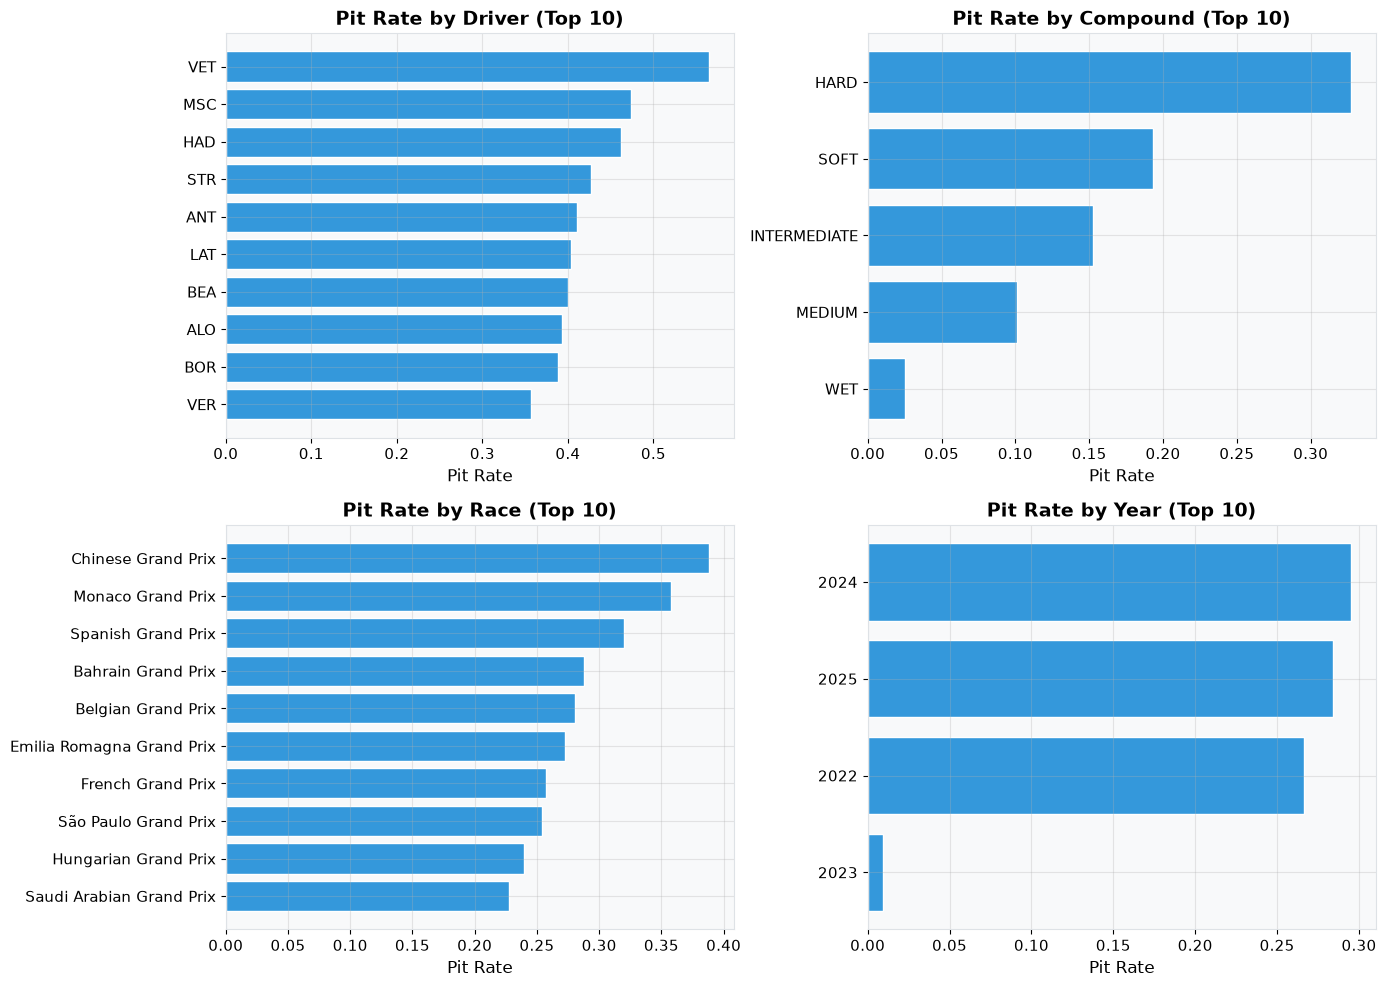

In [8]:
cat_cols = ["Driver", "Compound", "Race", "Year"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    pit_rate = train.groupby(col)[TARGET].mean().sort_values(ascending=False).head(10)
    ax.barh(range(len(pit_rate)), pit_rate.values, color="#3498db", edgecolor="white")
    ax.set_yticks(range(len(pit_rate)))
    ax.set_yticklabels(pit_rate.index)
    ax.set_xlabel("Pit Rate")
    ax.set_title(f"Pit Rate by {col} (Top 10)", fontweight="bold")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

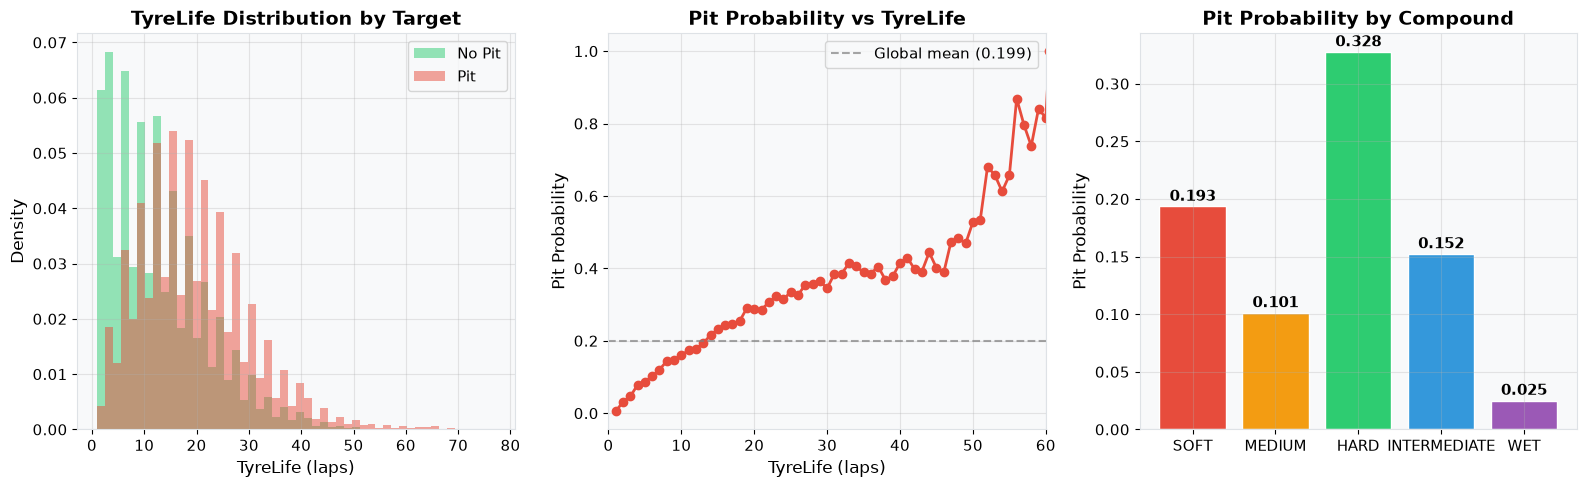

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# TyreLife distribution by target
ax = axes[0]
for target_val, color, label in [(0, "#2ecc71", "No Pit"), (1, "#e74c3c", "Pit")]:
    subset = train[train[TARGET] == target_val]
    ax.hist(subset["TyreLife"], bins=50, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel("TyreLife (laps)")
ax.set_ylabel("Density")
ax.set_title("TyreLife Distribution by Target", fontweight="bold")
ax.legend()

# Pit rate by TyreLife
ax = axes[1]
tyrelife_pit_rate = train.groupby("TyreLife")[TARGET].mean()
ax.plot(tyrelife_pit_rate.index, tyrelife_pit_rate.values, marker="o", color="#e74c3c", linewidth=2)
ax.axhline(train[TARGET].mean(), color="gray", linestyle="--", alpha=0.7, label=f"Global mean ({train[TARGET].mean():.3f})")
ax.set_xlabel("TyreLife (laps)")
ax.set_ylabel("Pit Probability")
ax.set_title("Pit Probability vs TyreLife", fontweight="bold")
ax.legend()
ax.set_xlim(0, 60)

# Pit rate by compound
ax = axes[2]
compound_order = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
compound_pit_rate = train.groupby("Compound")[TARGET].mean().reindex(compound_order)
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#3498db", "#9b59b6"]
bars = ax.bar(range(len(compound_pit_rate)), compound_pit_rate.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(compound_pit_rate)))
ax.set_xticklabels(compound_pit_rate.index)
ax.set_ylabel("Pit Probability")
ax.set_title("Pit Probability by Compound", fontweight="bold")
for bar, val in zip(bars, compound_pit_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

Pit probability rises steadily with tyre age, as expected. By compound, HARD tyres have the highest next-lap pit rate (0.33), ahead of SOFT (0.19) and MEDIUM (0.10). This is probably because hards are run to the end of long stints, so a hard-tyre lap is often close to a planned stop. WET laps rarely lead to a stop, since drivers stay out until conditions change.

## 3. Feature engineering

Each row is one lap for one driver. Sorting a driver's laps within a race (`Driver`, `Race`, `Year`, then `LapNumber`) lets us describe what led up to the current lap. Train and test laps come from the same races, so both are combined before building sequences. Only feature columns are shared, never the target.

The features use only the current and previous laps, which is the information a pit wall would have at that point in the race.

| Group | Examples | Idea |
|-------|----------|------|
| Lap sequence | Previous-lap tyre life, lap time, position and stint; laps since the last recorded lap; rolling 3-lap pace | How the driver's race has been developing |
| Stint pace | Average and best lap time so far on the current tyres | Whether the car is losing pace on this set of tyres |
| Tyre context | Typical tyre life for this race and compound, and the current tyre life relative to it | Whether the tyres are older than usual for this track |
| Race context | Race length and laps remaining | How much of the race is left to use a new set of tyres |
| Ratios | Tyre life per stint, degradation per lap, progress × tyre life | Relative rather than absolute wear |

In [10]:
GROUP = ["Driver", "Race", "Year"]
CAT_FEATURES = ["Driver", "Compound", "Race"]
SEQ_COLS = ["TyreLife", "LapTime (s)", "LapTime_Delta", "Position", "Stint", "PitStop", "Cumulative_Degradation"]


def build_features(train, test):
    df = pd.concat([train, test], ignore_index=True)
    df = df.sort_values(GROUP + ["LapNumber"]).reset_index(drop=True)
    g = df.groupby(GROUP, sort=False)

    # Lap sequence: the driver's previous recorded laps in this race
    df["laps_since_prev"] = g["LapNumber"].diff()
    df["lap_index"] = g.cumcount()
    for col in SEQ_COLS:
        df[f"{col}_prev1"] = g[col].shift(1)
        df[f"{col}_prev2"] = g[col].shift(2)
    df["stint_changed"] = df["Stint"] - df["Stint_prev1"]
    df["laptime_change"] = df["LapTime (s)"] - df["LapTime (s)_prev1"]
    df["position_change_since_prev"] = df["Position"] - df["Position_prev1"]
    df["degradation_change"] = df["Cumulative_Degradation"] - df["Cumulative_Degradation_prev1"]
    df["laptime_roll3"] = (
        g["LapTime (s)"].rolling(3, min_periods=1).mean().reset_index(level=GROUP, drop=True)
    )
    df["laptime_vs_roll3"] = df["LapTime (s)"] - df["laptime_roll3"]

    # Stint pace: lap times so far on the current set of tyres
    gs = df.groupby(GROUP + ["Stint"], sort=False)
    df["stint_laptime_mean"] = gs["LapTime (s)"].cumsum() / (gs.cumcount() + 1)
    df["laptime_vs_stint"] = df["LapTime (s)"] - df["stint_laptime_mean"]
    df["stint_best_laptime"] = gs["LapTime (s)"].cummin()

    # Tyre context: typical tyre life for this race and compound (no target used)
    grc = df.groupby(["Race", "Year", "Compound"])["TyreLife"]
    df["tyrelife_mean_race_compound"] = grc.transform("mean")
    df["tyrelife_std_race_compound"] = grc.transform("std")
    df["tyrelife_vs_typical"] = df["TyreLife"] / (df["tyrelife_mean_race_compound"] + 1)

    # Race context
    df["race_laps"] = (df["LapNumber"] / df["RaceProgress"].replace(0, np.nan)).round()
    df["laps_remaining"] = df["race_laps"] - df["LapNumber"]

    # Ratios and interactions
    df["tyrelife_per_stint"] = df["TyreLife"] / (df["Stint"] + 1)
    df["degradation_per_lap"] = df["Cumulative_Degradation"] / (df["TyreLife"] + 1)
    df["progress_x_tyrelife"] = df["RaceProgress"] * df["TyreLife"]

    for col in CAT_FEATURES:
        df[col] = df[col].astype("category")

    is_train = df[TARGET].notna()
    return df[is_train].reset_index(drop=True), df[~is_train].reset_index(drop=True)


train_fe, test_fe = build_features(train, test)

RAW_FEATURES = [c for c in train.columns if c not in (ID_COL, TARGET)]
FEATURES = [c for c in train_fe.columns if c not in (ID_COL, TARGET)]
y = train_fe[TARGET].astype(int).values

print(f"Raw features:        {len(RAW_FEATURES)}")
print(f"Engineered features: {len(FEATURES) - len(RAW_FEATURES)}")
print(f"Total features:      {len(FEATURES)}")

Raw features:        14
Engineered features: 33
Total features:      47


## 4. Models

LightGBM and CatBoost are trained on the same 5 stratified folds, so their out-of-fold (OOF) predictions line up row by row and can be blended. Each fold uses early stopping on its validation split, and test predictions are averaged across the five fold models.

In [11]:
folds = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(train_fe, y))

LGB_PARAMS = dict(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=127,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    random_state=SEED,
    verbose=-1,
)

CB_PARAMS = dict(
    iterations=5000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    eval_metric="AUC",
    random_seed=SEED,
    od_type="Iter",
    od_wait=200,
    verbose=0,
)


def run_lgb(features):
    oof, pred = np.zeros(len(train_fe)), np.zeros(len(test_fe))
    for k, (tr_idx, va_idx) in enumerate(folds):
        X_tr, X_va = train_fe.loc[tr_idx, features], train_fe.loc[va_idx, features]
        model = lgb.LGBMClassifier(**LGB_PARAMS)
        model.fit(
            X_tr, y[tr_idx],
            eval_set=[(X_va, y[va_idx])],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(200, verbose=False)],
        )
        oof[va_idx] = model.predict_proba(X_va)[:, 1]
        pred += model.predict_proba(test_fe[features])[:, 1] / N_FOLDS
        print(f"  fold {k + 1}: AUC {roc_auc_score(y[va_idx], oof[va_idx]):.4f} ({model.best_iteration_} trees)")
    print(f"  OOF AUC: {roc_auc_score(y, oof):.4f}")
    return oof, pred


def run_cb(features):
    cats = [c for c in CAT_FEATURES if c in features]

    def pool(df, label=None):
        X = df[features].copy()
        X[cats] = X[cats].astype(str)
        return cb.Pool(X, label, cat_features=cats)

    test_pool = pool(test_fe)
    oof, pred = np.zeros(len(train_fe)), np.zeros(len(test_fe))
    for k, (tr_idx, va_idx) in enumerate(folds):
        tr_pool = pool(train_fe.loc[tr_idx], y[tr_idx])
        va_pool = pool(train_fe.loc[va_idx], y[va_idx])
        model = cb.CatBoostClassifier(**CB_PARAMS)
        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)
        oof[va_idx] = model.predict_proba(va_pool)[:, 1]
        pred += model.predict_proba(test_pool)[:, 1] / N_FOLDS
        print(f"  fold {k + 1}: AUC {roc_auc_score(y[va_idx], oof[va_idx]):.4f} ({model.get_best_iteration()} trees)")
    print(f"  OOF AUC: {roc_auc_score(y, oof):.4f}")
    return oof, pred

### 4.1 LightGBM

In [12]:
print("LightGBM")
oof_lgb, pred_lgb = run_lgb(FEATURES)

LightGBM
  fold 1: AUC 0.9470 (1018 trees)
  fold 2: AUC 0.9456 (864 trees)
  fold 3: AUC 0.9452 (864 trees)
  fold 4: AUC 0.9446 (868 trees)
  fold 5: AUC 0.9447 (865 trees)
  OOF AUC: 0.9454


### 4.2 CatBoost

CatBoost handles the high-cardinality `Driver` and `Race` columns with ordered target statistics. This is the slowest step in the notebook.

In [13]:
print("CatBoost")
oof_cb, pred_cb = run_cb(FEATURES)

CatBoost
  fold 1: AUC 0.9504 (2246 trees)
  fold 2: AUC 0.9489 (2423 trees)
  fold 3: AUC 0.9489 (2701 trees)
  fold 4: AUC 0.9484 (2580 trees)
  fold 5: AUC 0.9486 (2391 trees)
  OOF AUC: 0.9490


LightGBM reaches 0.9454 OOF AUC and CatBoost 0.9490, with consistent scores across folds for both models.

## 5. Blending

The blend is a weighted average of the two models' probabilities: `w × CatBoost + (1 − w) × LightGBM`. The weight `w` is chosen by grid search on out-of-fold AUC. Only one parameter is fitted, so the risk of overfitting the OOF predictions is small.

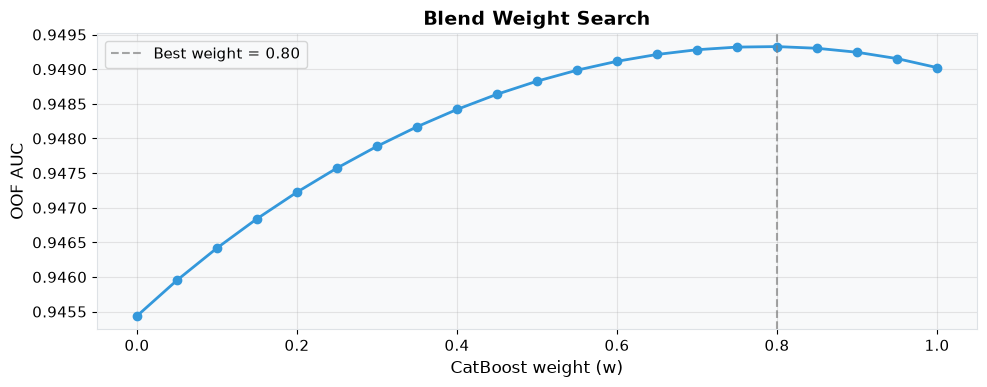

Best blend: 0.80 x CatBoost + 0.20 x LightGBM


In [14]:
weights = np.round(np.arange(0, 1.01, 0.05), 2)
blend_scores = [roc_auc_score(y, w * oof_cb + (1 - w) * oof_lgb) for w in weights]
best_w = float(weights[int(np.argmax(blend_scores))])
oof_blend = best_w * oof_cb + (1 - best_w) * oof_lgb
pred_blend = best_w * pred_cb + (1 - best_w) * pred_lgb

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weights, blend_scores, marker="o", color="#3498db", linewidth=2)
ax.axvline(best_w, color="gray", linestyle="--", alpha=0.7, label=f"Best weight = {best_w:.2f}")
ax.set_xlabel("CatBoost weight (w)")
ax.set_ylabel("OOF AUC")
ax.set_title("Blend Weight Search", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best blend: {best_w:.2f} x CatBoost + {1 - best_w:.2f} x LightGBM")

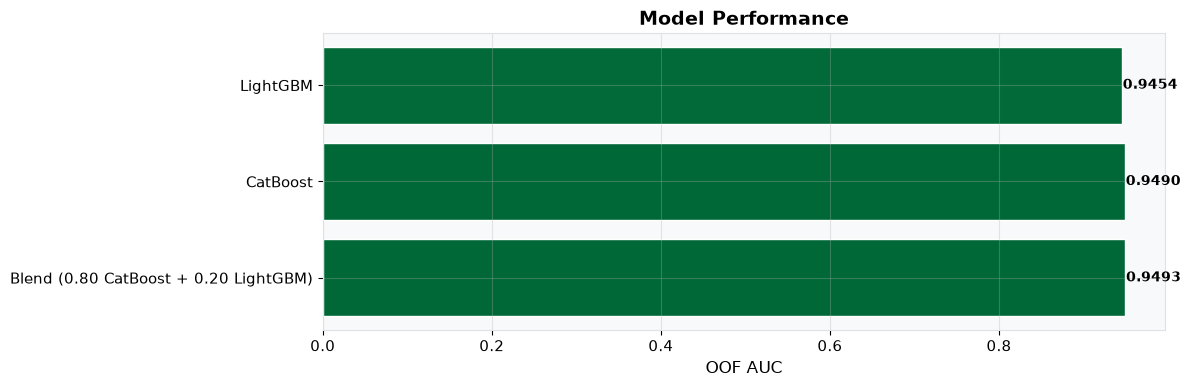

,Model,OOF AUC
0,LightGBM,0.9454
1,CatBoost,0.9490
2,Blend (0.80 CatBoost + 0.20 LightGBM),0.9493


In [15]:
results_df = pd.DataFrame({
    "Model": ["LightGBM", "CatBoost", f"Blend ({best_w:.2f} CatBoost + {1 - best_w:.2f} LightGBM)"],
    "OOF AUC": [roc_auc_score(y, p) for p in (oof_lgb, oof_cb, oof_blend)],
})

plot_df = results_df.sort_values("OOF AUC", ascending=True)
fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.RdYlGn(plot_df["OOF AUC"] / plot_df["OOF AUC"].max())
bars = ax.barh(range(len(plot_df)), plot_df["OOF AUC"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["Model"].values)
ax.set_xlabel("OOF AUC")
ax.set_title("Model Performance", fontweight="bold", fontsize=14)
ax.invert_yaxis()
for bar, val in zip(bars, plot_df["OOF AUC"].values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.4f}",
            va="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.show()

results_df.round(4)

The best blend puts 0.80 of the weight on CatBoost and 0.20 on LightGBM, giving 0.9493 OOF AUC, slightly above either model alone.

## 6. Save results and submission

In [16]:
submission = pd.DataFrame({ID_COL: test_fe[ID_COL].astype(int), TARGET: pred_blend}).sort_values(ID_COL)
submission.to_csv(OUT_DIR / "submission.csv", index=False)

summary = {
    "n_train_laps": int(len(train_fe)),
    "n_features": len(FEATURES),
    "oof_auc": {"LightGBM": round(roc_auc_score(y, oof_lgb), 4),
                "CatBoost": round(roc_auc_score(y, oof_cb), 4),
                "Blend (CatBoost + LightGBM)": round(roc_auc_score(y, oof_blend), 4)},
    "blend_weight_catboost": best_w,
}
with open(OUT_DIR / "cv_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(f"\nSaved {len(submission):,} predictions to {OUT_DIR / 'submission.csv'}")

{
  "n_train_laps": 439140,
  "n_features": 47,
  "oof_auc": {
    "LightGBM": 0.9454,
    "CatBoost": 0.949,
    "Blend (CatBoost + LightGBM)": 0.9493
  },
  "blend_weight_catboost": 0.8
}

Saved 188,165 predictions to outputs/submission.csv


## 7. Conclusions

- Tyre age, stint number and race progress explain most pit decisions. No single feature is strongly correlated with the target, so gradient-boosted trees suit this problem well.
- CatBoost was the stronger model (0.9490 against 0.9454 for LightGBM).
- Blending the two gave the best result, 0.9493 OOF AUC.

Next steps:
- Add external context such as weather, safety-car periods and track characteristics.